In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_classif, f_classif
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve, accuracy_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
SEED = 42
print('All libraries loaded.')

All libraries loaded.


In [ ]:
URL = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
)
COL_NAMES = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df = pd.read_csv(URL, header=None, names=COL_NAMES,
                 na_values=' ?', skipinitialspace=True)

print(f'Shape: {df.shape}')
df.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe(include='all')

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,32561.000000,32561,3.256100e+04,32561,32561.000000,32561,32561,32561,32561,32561,32561.000000,32561.000000,32561.000000,32561,32561
unique,NaN,9,NaN,16,NaN,7,15,6,5,2,NaN,NaN,NaN,42,2
top,NaN,Private,NaN,HS-grad,NaN,Married-civ-spouse,Prof-specialty,Husband,White,Male,NaN,NaN,NaN,United-States,<=50K
freq,NaN,22696,NaN,10501,NaN,14976,4140,13193,27816,21790,NaN,NaN,NaN,29170,24720
mean,38.581647,NaN,1.897784e+05,NaN,10.080679,NaN,NaN,NaN,NaN,NaN,1077.648844,87.303830,40.437456,NaN,NaN
std,13.640433,NaN,1.055500e+05,NaN,2.572720,NaN,NaN,NaN,NaN,NaN,7385.292085,402.960219,12.347429,NaN,NaN
min,17.000000,NaN,1.228500e+04,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN
25%,28.000000,NaN,1.178270e+05,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
50%,37.000000,NaN,1.783560e+05,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,40.000000,NaN,NaN
75%,48.000000,NaN,2.370510e+05,NaN,12.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,45.000000,NaN,NaN


### Feature Engineering

In [ ]:
df['capital_net']        = df['capital_gain'] - df['capital_loss']
df['has_capital_gain']   = (df['capital_gain'] > 0).astype(int)
df['has_capital_loss']   = (df['capital_loss'] > 0).astype(int)
df['age_group']          = pd.cut(df['age'],
                                   bins=[0, 25, 35, 50, 65, 100],
                                   labels=['young', 'early_career',
                                           'mid_career', 'senior', 'retired'])
df['hours_group']        = pd.cut(df['hours_per_week'],
                                   bins=[0, 20, 40, 60, 100],
                                   labels=['part_time', 'full_time',
                                           'overtime', 'extreme'])
df['is_married']         = df['marital_status'].isin(
                              ['Married-civ-spouse', 'Married-AF-spouse']).astype(int)
df['is_us_native']       = (df['native_country'] == 'United-States').astype(int)
df['high_edu']           = (df['education_num'] >= 13).astype(int)

print(f'Shape after feature engineering: {df.shape}')
print(f'Total features : {df.shape[1] - 1}')

Shape after feature engineering: (32561, 23)
Total features : 22


In [ ]:
df['income'] = (df['income'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)

X = df.drop(columns=['income'])
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test  size : {X_test.shape}')
print(f'Class balance (train): {y_train.value_counts(normalize=True).to_dict()}')

Train size : (26048, 22)
Test  size : (6513, 22)
Class balance (train): {0: 0.7591753685503686, 1: 0.24082463144963145}


---
## 2. Exploratory Data Analysis (EDA)
All EDA is performed on the **training set only** to prevent leakage.

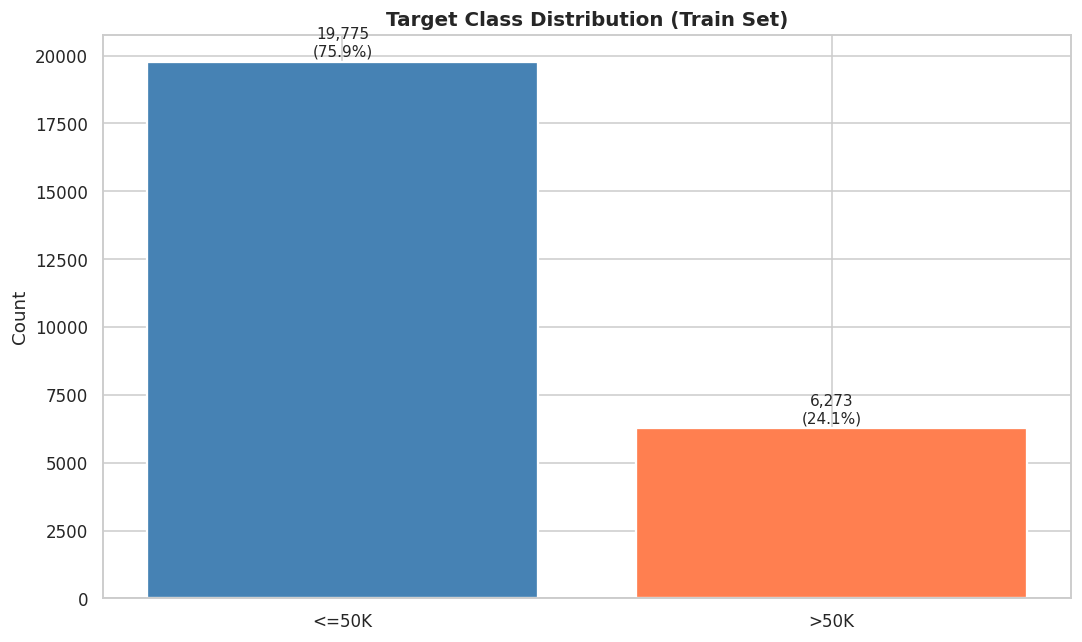

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
counts = y_train.value_counts()
ax.bar(['<=50K', '>50K'], counts.values, color=['steelblue', 'coral'], edgecolor='white', linewidth=1.5)
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f'{v:,}\n({v/len(y_train)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution (Train Set)', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

Data imbalance  

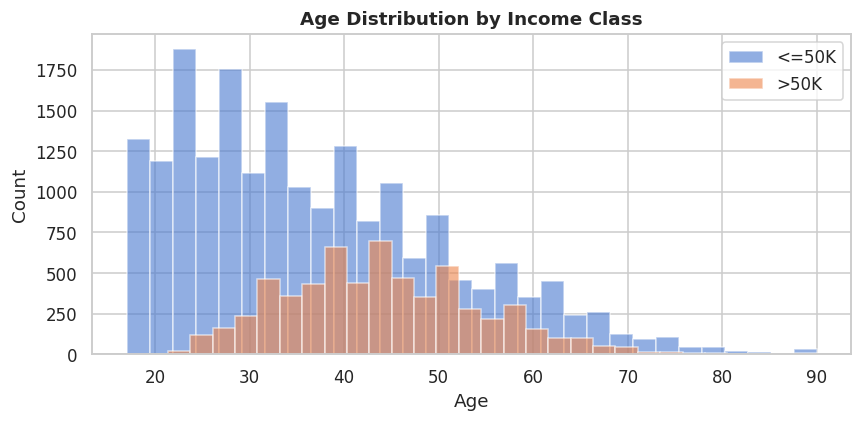

In [ ]:
train_eda = X_train.copy()
train_eda['income'] = y_train.values

fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in train_eda.groupby('income'):
    ax.hist(grp['age'], bins=30, alpha=0.6,
            label='>50K' if label == 1 else '<=50K', edgecolor='white')
ax.set_title('Age Distribution by Income Class', fontweight='bold')
ax.set_xlabel('Age'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout(); plt.show()

**Age** is a strong and informative feature. The feature engineering we applied (age_group) helps the model capture this non-linear pattern even better than the raw number alone

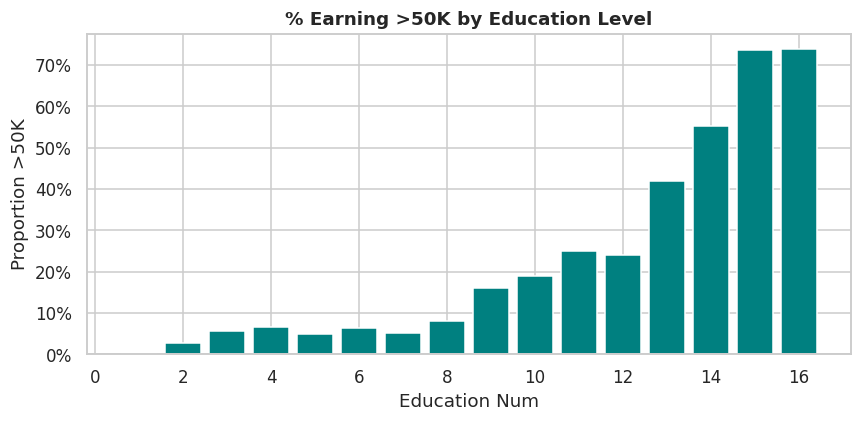

In [ ]:
edu_income = (train_eda.groupby('education_num')['income']
              .mean().reset_index(name='pct_high_income'))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(edu_income['education_num'], edu_income['pct_high_income'],
       color='teal', edgecolor='white')
ax.set_title('% Earning >50K by Education Level', fontweight='bold')
ax.set_xlabel('Education Num'); ax.set_ylabel('Proportion >50K')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout(); plt.show()

**Almost perfectly linear
The higher the education level, the higher the chance of earning >50K**

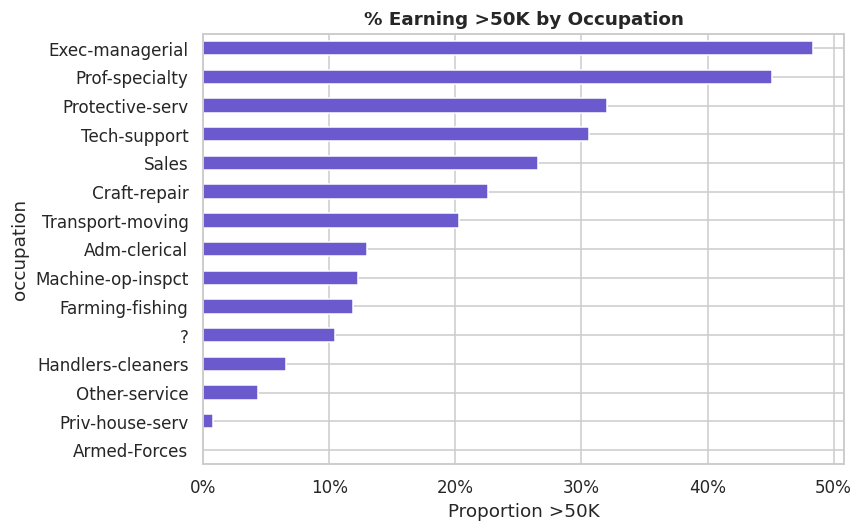

In [ ]:
occ_income = (train_eda.groupby('occupation')['income']
              .mean().sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))
occ_income.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('% Earning >50K by Occupation', fontweight='bold')
ax.set_xlabel('Proportion >50K')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout(); plt.show()

**occupation** is a highly discriminative feature

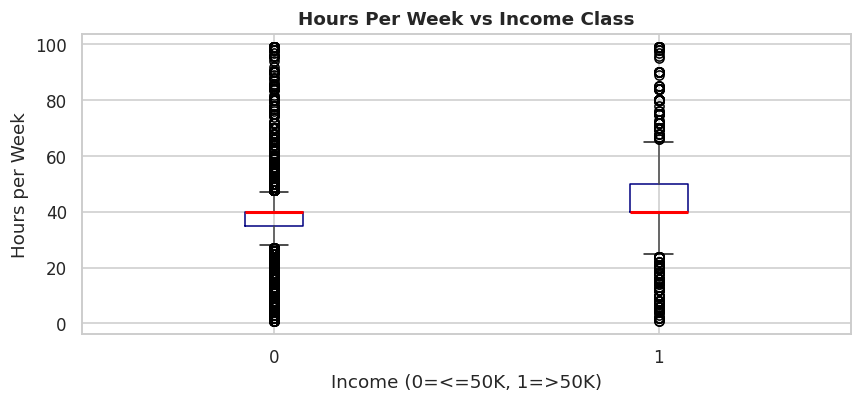

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
train_eda.boxplot(column='hours_per_week', by='income', ax=ax,
                  boxprops=dict(color='navy'),
                  medianprops=dict(color='red', linewidth=2))
ax.set_title('Hours Per Week vs Income Class', fontweight='bold')
ax.set_xlabel('Income (0=<=50K, 1=>50K)')
ax.set_ylabel('Hours per Week')
plt.suptitle('')
plt.tight_layout(); plt.show()

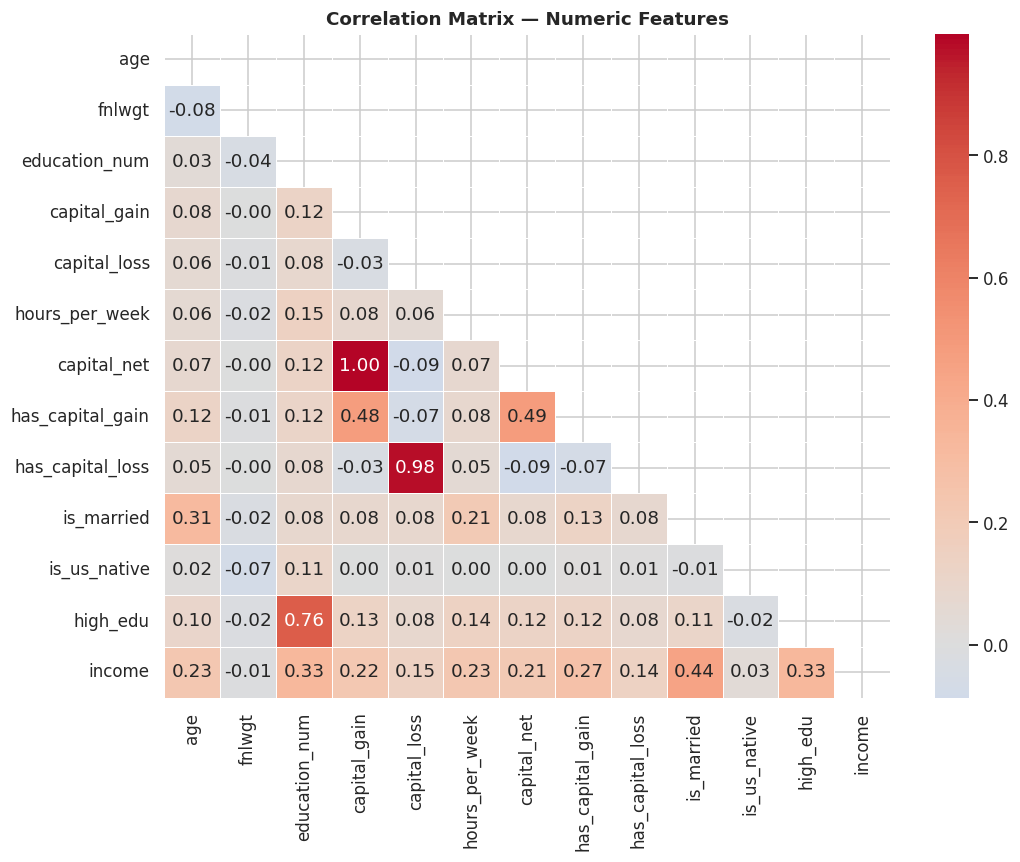

In [ ]:
num_cols = train_eda.select_dtypes(include=np.number).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr = train_eda[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=12)
plt.tight_layout(); plt.show()

**The pairs with correlation > 0.90 (capital_loss/has_capital_loss and capital_gain/capital_net) are redundant features**

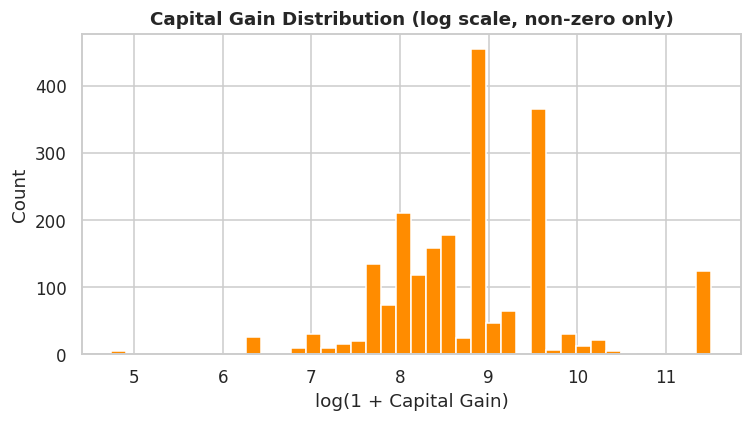

In [ ]:
nonzero_cg = train_eda.loc[train_eda['capital_gain'] > 0, 'capital_gain']

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log1p(nonzero_cg), bins=40, color='darkorange', edgecolor='white')
ax.set_title('Capital Gain Distribution (log scale, non-zero only)', fontweight='bold')
ax.set_xlabel('log(1 + Capital Gain)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

The **has_capital_gain** feature (0 or 1) will likely rank very high in the MI filter because simply having investments strongly separates the two income classes.

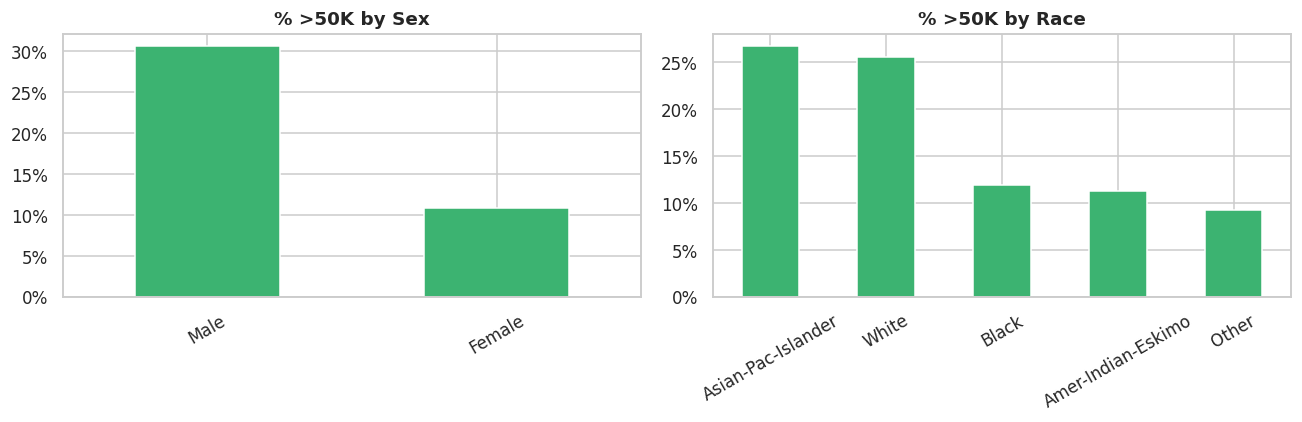

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['sex', 'race']):
    grp = (train_eda.groupby(col)['income']
           .mean().sort_values(ascending=False))
    grp.plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white', rot=30)
    ax.set_title(f'% >50K by {col.title()}', fontweight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax.set_xlabel('')

plt.tight_layout(); plt.show()

***Massive gender*** **gap** — nearly 3x difference
Males are almost 3 times more likely to earn >50K than females

In [ ]:
import numpy as np
missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

if not missing_train.empty:
    fig, ax = plt.subplots(figsize=(6, 3))
    missing_train.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
    ax.set_title('Missing Values Count (Train Set)', fontweight='bold')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()
    print(missing_train)
else:
    print('No missing values found in the training set.')


No missing values found in the training set.


---
## 3. Data Cleaning
Cleaning is **fit on train, applied to both train and test** (handled inside the pipeline).  
Here we document findings and decisions.

In [ ]:
print('=== Train Missing ===')
print(X_train.isnull().sum())
print('\n=== Test Missing ===')
print(X_test.isnull().sum())

=== Train Missing ===
age                 0
workclass           0
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation          0
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country      0
capital_net         0
has_capital_gain    0
has_capital_loss    0
age_group           0
hours_group         0
is_married          0
is_us_native        0
high_edu            0
dtype: int64

=== Test Missing ===
age                 0
workclass           0
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation          0
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country      0
capital_net         0
has_capital_gain    0
has_capital_loss    0
age_group           0
hours_group         0
is_married          0
is_us_native       

In [ ]:
num_features = X_train.select_dtypes(include=['int'])

outlier_summary = {}
for col in num_features:
    Q1, Q3 = X_train[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((X_train[col] < Q1 - 1.5*IQR) | (X_train[col] > Q3 + 1.5*IQR)).sum()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Outliers': n_out}

out_df = pd.DataFrame(outlier_summary).T
print(out_df)
print("\nDecision: Outliers in capital_gain/loss are genuine (high earners). "
      "We cap using IQR winsorization inside the pipeline instead of dropping records.")

                         Q1         Q3       IQR  Outliers
age                   28.00      48.00      20.0     118.0
fnlwgt            118194.25  237457.75  119263.5     779.0
education_num          9.00      12.00       3.0     990.0
capital_gain           0.00       0.00       0.0    2149.0
capital_loss           0.00       0.00       0.0    1223.0
hours_per_week        40.00      45.00       5.0    7225.0
capital_net            0.00       0.00       0.0    3372.0
has_capital_gain       0.00       0.00       0.0    2149.0
has_capital_loss       0.00       0.00       0.0    1223.0
is_married             0.00       1.00       1.0       0.0
is_us_native           1.00       1.00       0.0    2713.0
high_edu               0.00       0.00       0.0    6455.0

Decision: Outliers in capital_gain/loss are genuine (high earners). We cap using IQR winsorization inside the pipeline instead of dropping records.


In [ ]:
dupes = X_train.duplicated().sum()
print(f'Duplicate rows in train: {dupes}')


Duplicate rows in train: 17


In [ ]:
X_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 26048 entries, 15738 to 5800
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               26048 non-null  int64   
 1   workclass         26048 non-null  object  
 2   fnlwgt            26048 non-null  int64   
 3   education         26048 non-null  object  
 4   education_num     26048 non-null  int64   
 5   marital_status    26048 non-null  object  
 6   occupation        26048 non-null  object  
 7   relationship      26048 non-null  object  
 8   race              26048 non-null  object  
 9   sex               26048 non-null  object  
 10  capital_gain      26048 non-null  int64   
 11  capital_loss      26048 non-null  int64   
 12  hours_per_week    26048 non-null  int64   
 13  native_country    26048 non-null  object  
 14  capital_net       26048 non-null  int64   
 15  has_capital_gain  26048 non-null  int64   
 16  has_capital_loss  26048 

In [ ]:
num_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain',
            'capital_loss', 'hours_per_week', 'capital_net',
            'has_capital_gain', 'has_capital_loss',
            'is_married', 'is_us_native', 'high_edu']


cat_cols = ['workclass', 'education', 'marital_status', 'occupation',
            'relationship', 'race', 'sex', 'native_country',
            'age_group', 'hours_group']

print(f'Numeric features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Total features used: {len(num_cols) + len(cat_cols)}')

Numeric features  : 12
Categorical features: 10
Total features used: 22


---
## 4. Dimensionality Reduction

We apply the three families of techniques studied in the course **in sequence**:

| Step | Method | Type |
|------|--------|------|
| 4.1 | **Variance Filter** | Filter |
||
| 4.2 | **Correlation Filter** | Filter |
||
| 4.3 | **Mutual Information (IG)** | Filter |
| |
| 4.4 | **PCA** | Transformation |



In [ ]:
from sklearn.preprocessing import OneHotEncoder

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f'Shape after preprocessing: {X_train_prep.shape}')

Shape after preprocessing: (26048, 22)


### 4.1 Filter Method — Variance Threshold

Features before: 22
Features after Variance Filter: 11
Removed (near-zero variance): 11


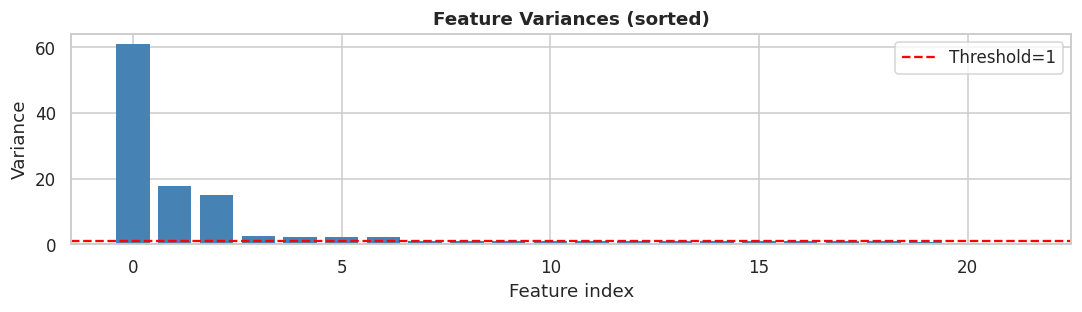

In [ ]:
vt = VarianceThreshold(threshold=1)
X_vt = vt.fit_transform(X_train_prep)
removed_vt = X_train_prep.shape[1] - X_vt.shape[1]
print(f'Features before: {X_train_prep.shape[1]}')
print(f'Features after Variance Filter: {X_vt.shape[1]}')
print(f'Removed (near-zero variance): {removed_vt}')


variances = vt.variances_
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(variances)), sorted(variances, reverse=True),
       color='steelblue', edgecolor='none')
ax.axhline(1, color='red', linestyle='--', label='Threshold=1')
ax.set_title('Feature Variances (sorted)', fontweight='bold')
ax.set_xlabel('Feature index'); ax.set_ylabel('Variance')
ax.legend()
plt.tight_layout(); plt.show()

### 4.2 Filter Method — Correlation Filter

In [ ]:
X_vt_train = vt.transform(X_train_prep)


corr_matrix = np.corrcoef(X_vt_train.T)
upper = np.triu(np.abs(corr_matrix), k=1)

CORR_THRESHOLD = 0.90
to_drop_corr = set()
for i in range(upper.shape[1]):
    for j in range(i+1, upper.shape[1]):
        if upper[i, j] > CORR_THRESHOLD:
            to_drop_corr.add(j)

keep_corr = [i for i in range(X_vt_train.shape[1]) if i not in to_drop_corr]
X_corr = X_vt_train[:, keep_corr]
print(f'Features after Correlation Filter (|r|>{CORR_THRESHOLD}): {X_corr.shape[1]}')
print(f'Removed: {len(to_drop_corr)}')

Features after Correlation Filter (|r|>0.9): 11
Removed: 0


### 4.3 Filter Method — Information Gain (Mutual Information)

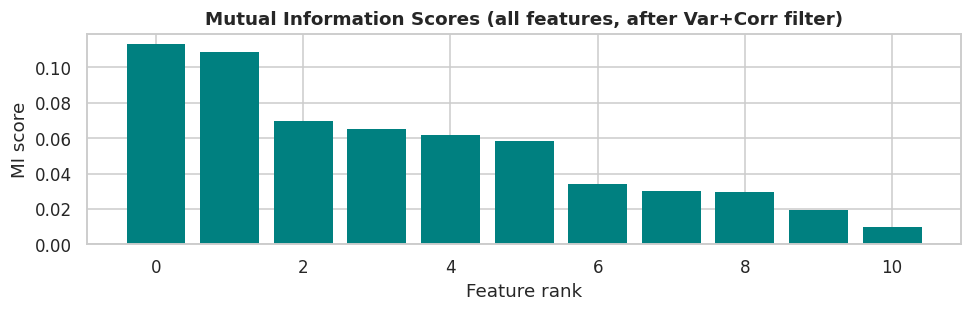

Features selected by MI (top 18): 11


In [ ]:
mi = mutual_info_classif(X_corr, y_train, random_state=SEED)
mi_series = pd.Series(mi, name='MI').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 3))
mi_series.values[:20]
ax.bar(range(len(mi_series)), mi_series.values, color='teal', edgecolor='none')
ax.set_title('Mutual Information Scores (all features, after Var+Corr filter)',
             fontweight='bold')
ax.set_xlabel('Feature rank'); ax.set_ylabel('MI score')
plt.tight_layout(); plt.show()

K_MI = 18
top_mi_idx = mi_series.index[:K_MI].tolist()
X_mi = X_corr[:, top_mi_idx]
print(f'Features selected by MI (top {K_MI}): {X_mi.shape[1]}')

### 4.4 PCA — Final Dimensionality Reduction

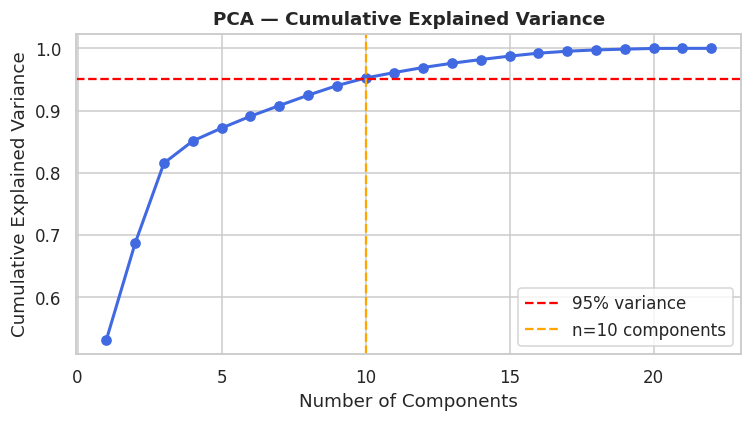

Components needed for 95% variance: 10


In [ ]:
pca_exp = PCA(random_state=SEED)
pca_exp.fit(X_train_prep)

cumvar = np.cumsum(pca_exp.explained_variance_ratio_)
n_components_95 = np.searchsorted(cumvar, 0.95) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='royalblue', linewidth=2)
ax.axhline(0.95, color='red', linestyle='--', label='95% variance')
ax.axvline(n_components_95, color='orange', linestyle='--',
           label=f'n={n_components_95} components')
ax.set_title('PCA — Cumulative Explained Variance', fontweight='bold')
ax.set_xlabel('Number of Components'); ax.set_ylabel('Cumulative Explained Variance')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Components needed for 95% variance: {n_components_95}')

---
## 5. Full Pipeline — Preprocessing + DR + SVM

We integrate all steps into a single `sklearn.Pipeline` to avoid leakage and simplify deployment.

In [ ]:
from sklearn.feature_selection import SelectKBest

pipeline = Pipeline([

    ('preprocessor', preprocessor),


    ('variance_filter', VarianceThreshold(threshold=0.01)),


    ('mi_filter', SelectKBest(score_func=mutual_info_classif, k=18)),


    ('pca', PCA(n_components=n_components_95, random_state=SEED)),


    ('svm', SVC(gamma='scale',C=0.1,kernel='rbf',probability=True, random_state=SEED))
])

print('Pipeline created:')
print(pipeline)

Pipeline created:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week',
                                                   'capital_net',
                                                   'has_capital_gain',
                                                   'has_capital_loss',


### 5.1  SVM (default parameters)

In [ ]:
pipeline.fit(X_train, y_train)
y_pred_base = pipeline.predict(X_test)
print(' Baseline SVM Performance ')
print(classification_report(y_test, y_pred_base, target_names=['<=50K', '>50K']))
print(f"The score is :  {pipeline.score(X_test, y_test)}")

 Baseline SVM Performance 
              precision    recall  f1-score   support

       <=50K       0.85      0.95      0.90      4945
        >50K       0.75      0.48      0.59      1568

    accuracy                           0.84      6513
   macro avg       0.80      0.71      0.74      6513
weighted avg       0.83      0.84      0.82      6513

The score is :  0.8357131890066022


### 5.2 Hyperparameter Tuning (GridSearchCV)

In [ ]:
param_grid = {
    'svm__C':      [0.1, 1],
    'svm__kernel': ['rbf', 'linear'],
    'svm__gamma':  ['scale', 'auto'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters : {'svm__C': 1, 'svm__gamma': 'auto', 'svm__kernel': 'rbf'}
Best CV : 0.6293


---
## 6. Final Model Evaluation

In [ ]:
best_model = grid_search.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print('=== Final Model — Test Set Performance ===')
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')


=== Final Model — Test Set Performance ===
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      4945
        >50K       0.74      0.56      0.64      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.75      0.77      6513
weighted avg       0.84      0.85      0.84      6513

ROC-AUC : 0.8798
The score is :  0.8357131890066022


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import pandas as pd

y_proba_base = pipeline.predict_proba(X_test)[:, 1]

baseline_accuracy = pipeline.score(X_test, y_test)
baseline_report = classification_report(y_test, y_pred_base, output_dict=True)
baseline_precision_pos = baseline_report['1']['precision']
baseline_recall_pos = baseline_report['1']['recall']
baseline_f1_pos = baseline_report['1']['f1-score']
baseline_roc_auc = roc_auc_score(y_test, y_proba_base)



tuned_accuracy = accuracy_score(y_test, y_pred)
tuned_report = classification_report(y_test, y_pred, output_dict=True)
tuned_precision_pos = tuned_report['1']['precision']
tuned_recall_pos = tuned_report['1']['recall']
tuned_f1_pos = tuned_report['1']['f1-score']
tuned_roc_auc = roc_auc_score(y_test, y_proba)


comparison_data = {
    'Model': ['Baseline SVM', 'Tuned SVM'],
    'Accuracy': [baseline_accuracy, tuned_accuracy],
    'Precision (>50K)': [baseline_precision_pos, tuned_precision_pos],
    'Recall (>50K)': [baseline_recall_pos, tuned_recall_pos],
    'F1-Score (>50K)': [baseline_f1_pos, tuned_f1_pos],
    'ROC-AUC': [baseline_roc_auc, tuned_roc_auc]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n Model Performance Comparison")
print(comparison_df.round(6).to_markdown(index=False))




 Model Performance Comparison
| Model        |   Accuracy |   Precision (>50K) |   Recall (>50K) |   F1-Score (>50K) |   ROC-AUC |
|:-------------|-----------:|-------------------:|----------------:|------------------:|----------:|
| Baseline SVM |   0.835713 |           0.746047 |        0.481505 |          0.585271 |  0.878907 |
| Tuned SVM    |   0.846768 |           0.741525 |        0.558036 |          0.636827 |  0.879783 |


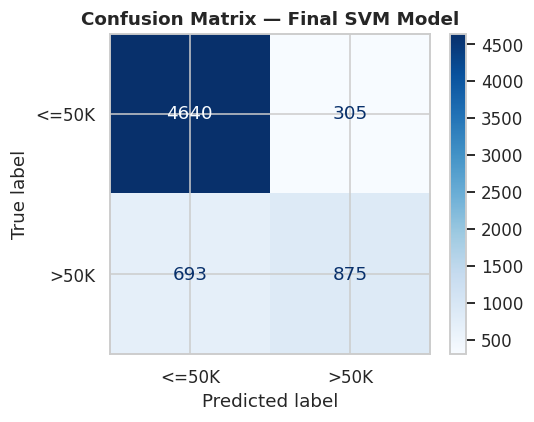

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Final SVM Model', fontweight='bold')
plt.tight_layout(); plt.show()

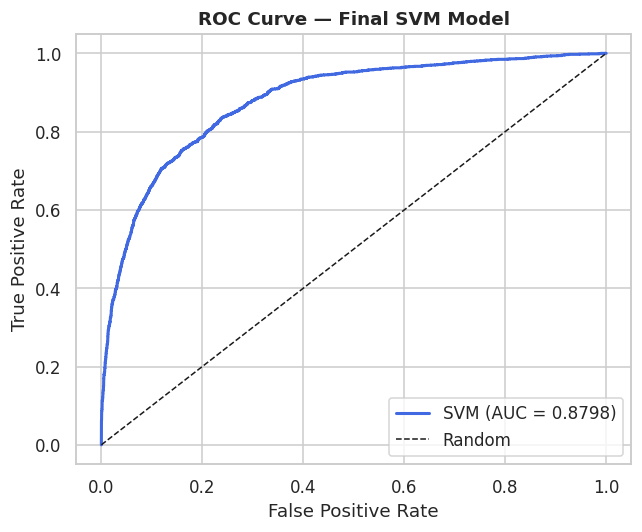

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='royalblue', lw=2, label=f'SVM (AUC = {auc_val:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_title('ROC Curve — Final SVM Model', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-Score' : f1_score(y_test, y_pred),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba)
}

pd.DataFrame([results], index=['SVM (tuned)']).round(4)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM (tuned),0.8468,0.7415,0.558,0.6368,0.8798
